In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('/content/customer_churn_dataset-testing-master.csv')

# Display first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [ ]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (64374, 12)

Column Names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-nul

In [ ]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [ ]:
# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# Display unique values of each column
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:20])


CustomerID:
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Age:
[22 41 47 35 53 30 54 36 65 46 56 31 42 59 29 45 62 48 55 64]

Gender:
['Female' 'Male']

Tenure:
[25 28 27  9 58 41 37 36 20  8 42 13  2 46 21  1 54 40 39 50]

Usage Frequency:
[14 28 10 12 24 15 11  5  4 27 23  7 17  3 30  2 19 20 18  8]

Support Calls:
[ 4  7  2  5  9 10  0  6  1  3  8]

Payment Delay:
[27 13 29 17  2 10 28 18  8 23 21 14 25  3  6 15  1  9 30  4]

Subscription Type:
['Basic' 'Standard' 'Premium']

Contract Length:
['Monthly' 'Annual' 'Quarterly']

Total Spend:
[598 584 757 232 533 500 574 323 687 995 526 187 758 438 663 677 636 127
 396 202]

Last Interaction:
[ 9 20 21 18 29 14 16  8 10  3  1 24 30 15 25 22 13 26 12  4]

Churn:
[1 0]


In [ ]:
# Statistical summary of numerical columns
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [ ]:
# Churn distribution
print(df['Churn'].value_counts())

# Churn percentage
print("\nChurn Percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
0    33881
1    30493
Name: count, dtype: int64

Churn Percentage:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


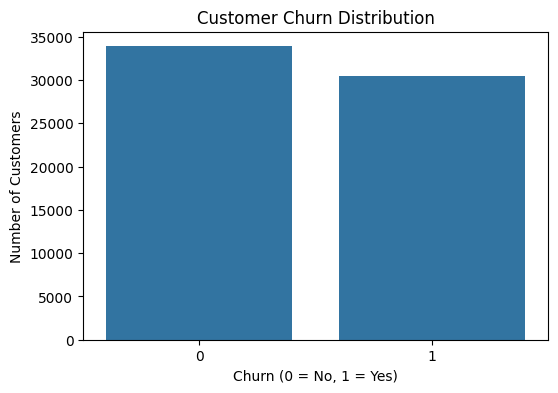

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x='Churn')

plt.title('Customer Churn Distribution')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')

plt.show()

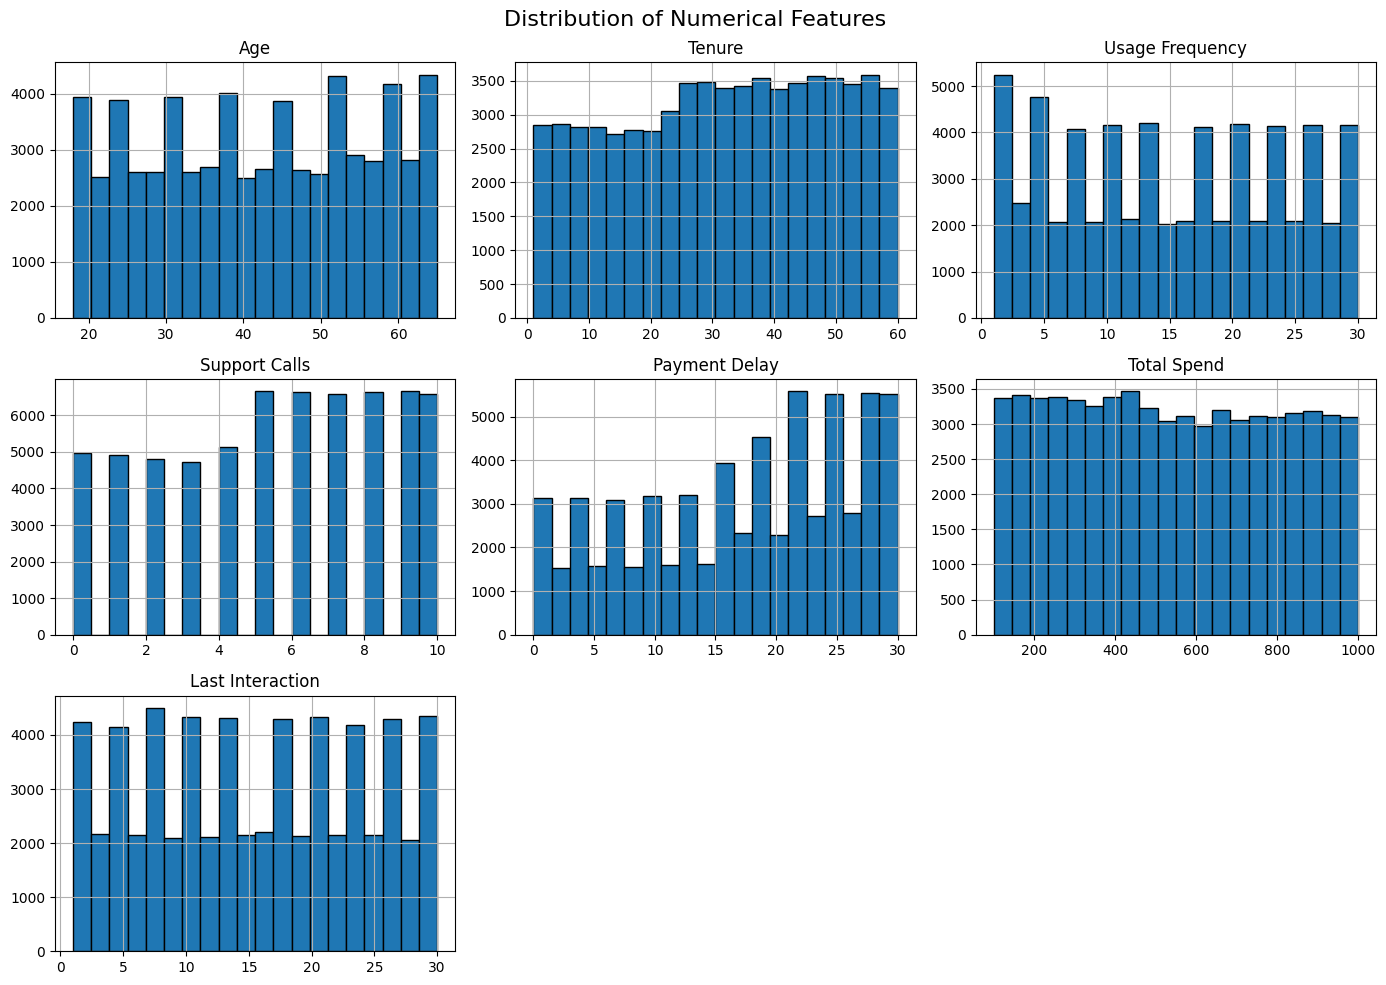

In [ ]:
numerical_columns = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

df[numerical_columns].hist(
    figsize=(14, 10),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
categorical_columns = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts())


Gender
Gender
Female    34353
Male      30021
Name: count, dtype: int64

Subscription Type
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64

Contract Length
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64


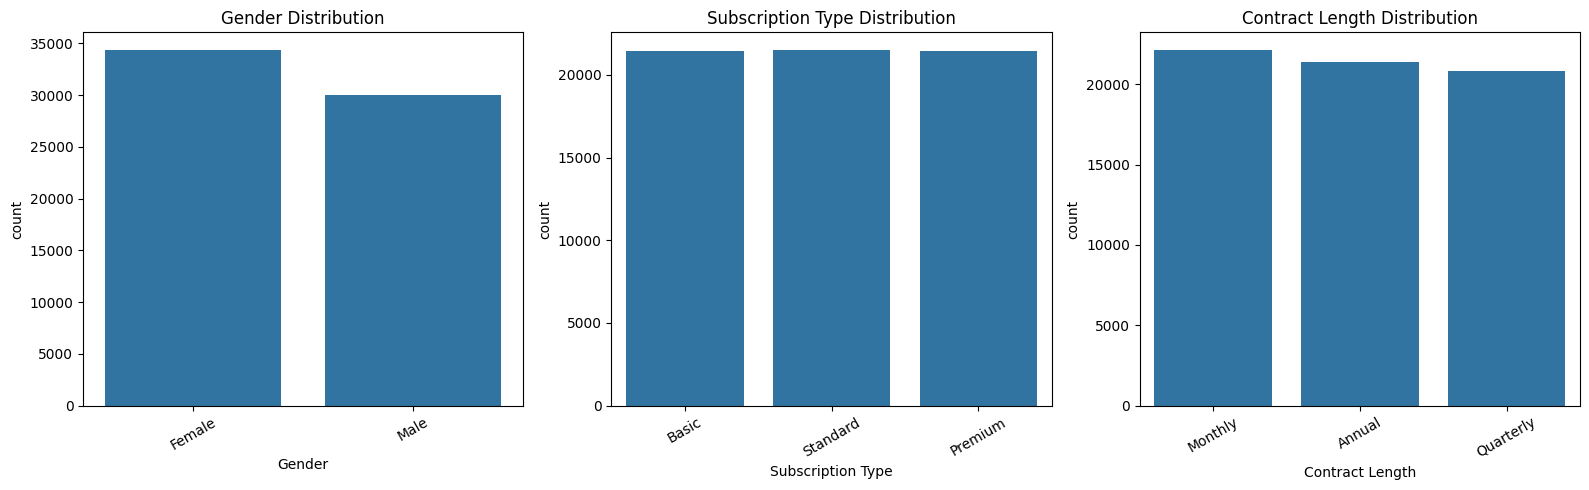

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, column in enumerate(categorical_columns):
    sns.countplot(data=df, x=column, ax=axes[i])
    axes[i].set_title(f'{column} Distribution')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

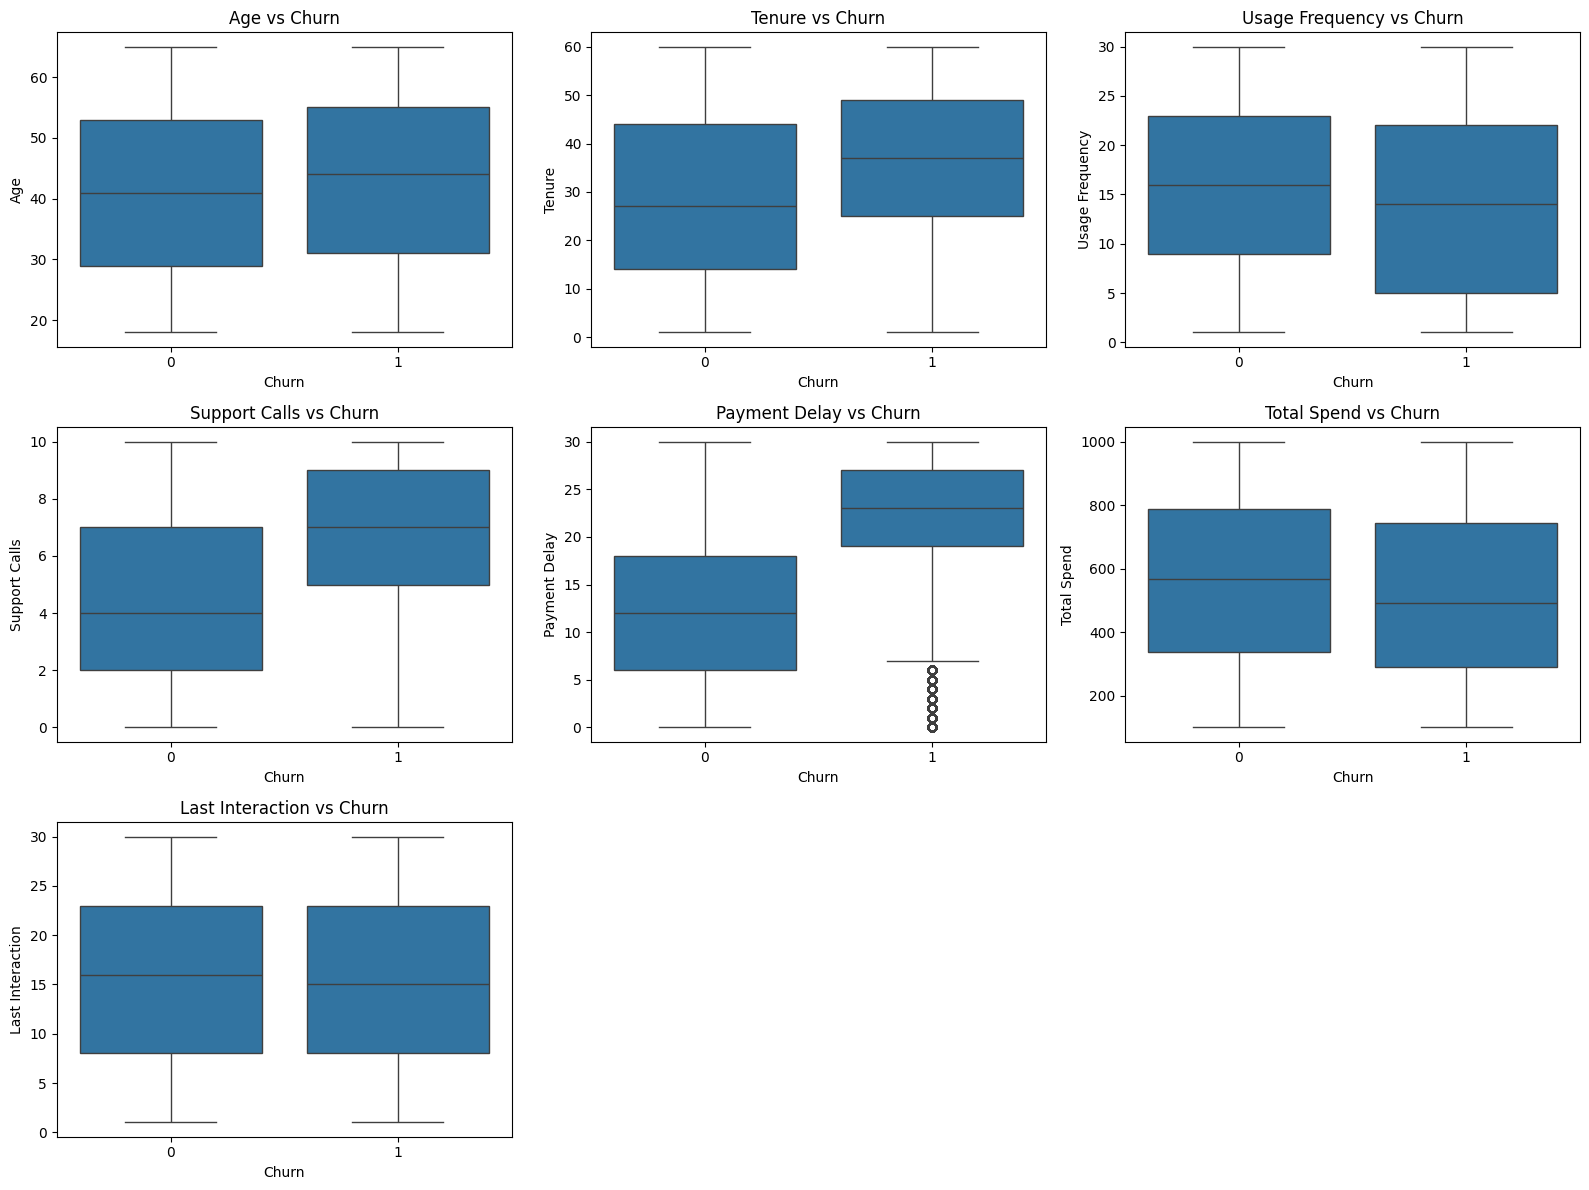

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for i, column in enumerate(numerical_columns):
    row = i // 3
    col = i % 3

    sns.boxplot(
        data=df,
        x='Churn',
        y=column,
        ax=axes[row, col]
    )

    axes[row, col].set_title(f'{column} vs Churn')

# Hide unused subplot
axes[2, 1].axis('off')
axes[2, 2].axis('off')

plt.tight_layout()
plt.show()

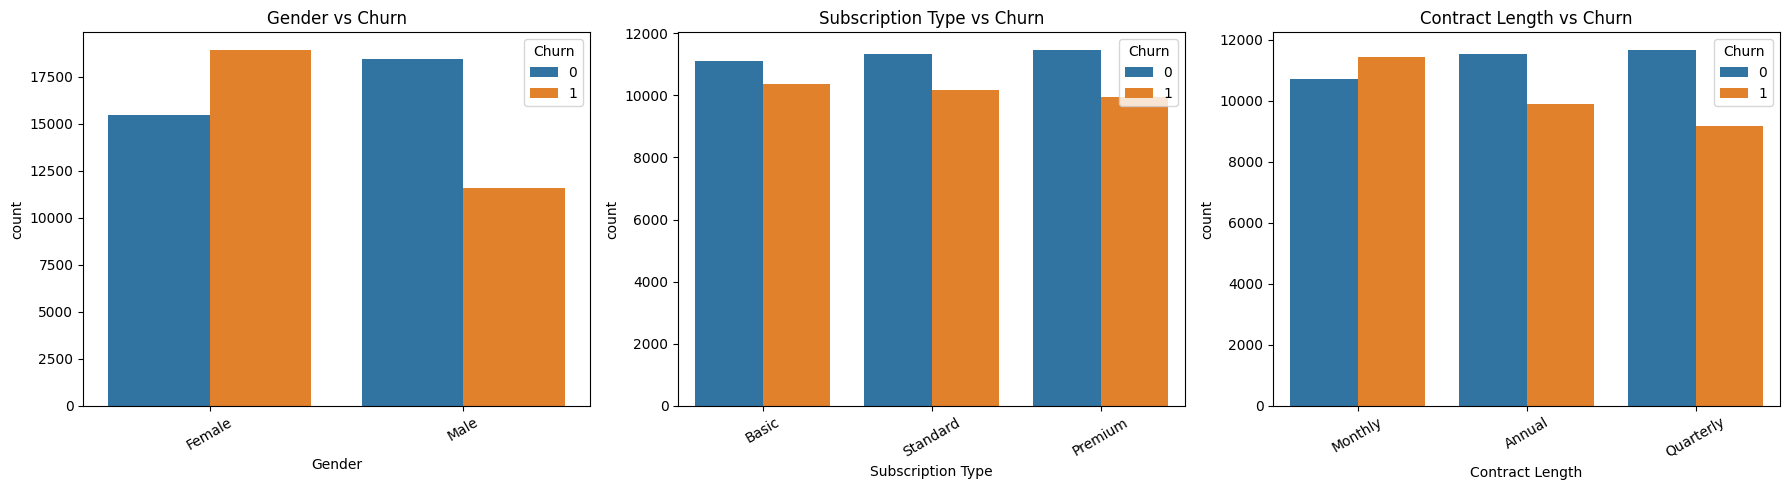

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, column in enumerate(categorical_columns):
    sns.countplot(
        data=df,
        x=column,
        hue='Churn',
        ax=axes[i]
    )

    axes[i].set_title(f'{column} vs Churn')
    axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

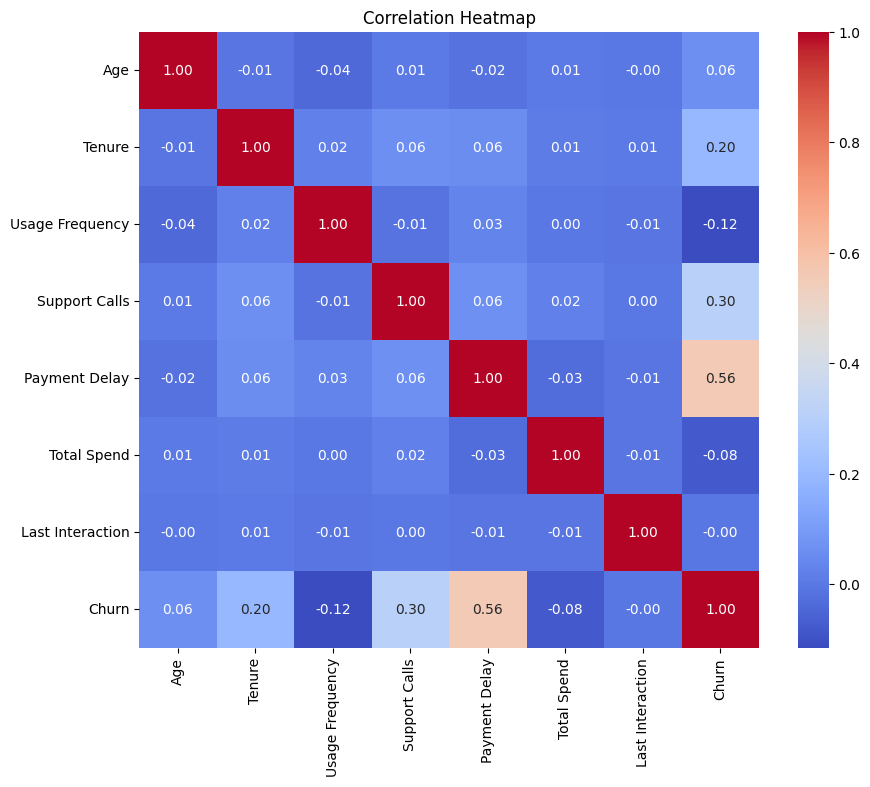

In [ ]:
plt.figure(figsize=(10, 8))

correlation = df[numerical_columns + ['Churn']].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
# Check missing values
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [ ]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (64374, 12)


In [ ]:
# Remove CustomerID
df_model = df.drop('CustomerID', axis=1)

# Separate features and target
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Target:
Churn


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

numerical_features = [
    'Age',
    'Tenure',
    'Usage Frequency',
    'Support Calls',
    'Payment Delay',
    'Total Spend',
    'Last Interaction'
]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (51499, 10)
Testing set: (12875, 10)


In [ ]:
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Tenure',
                                                   'Usage Frequency',
                                                   'Support Calls',
                                                   'Payment Delay',
                                                   'Total Spend',
                                                   'Last Interaction']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender',
                                                   'Subscription Type',
                                                   'Contract Length'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [ ]:
y_pred_logistic = logistic_model.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall   :", recall_score(y_test, y_pred_logistic))
print("F1 Score :", f1_score(y_test, y_pred_logistic))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
--------------------------------
Accuracy : 0.8270291262135923
Precision: 0.8136746597537265
Recall   : 0.823413674372848
F1 Score : 0.8185151984353354

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.83      6776
           1       0.81      0.82      0.82      6099

    accuracy                           0.83     12875
   macro avg       0.83      0.83      0.83     12875
weighted avg       0.83      0.83      0.83     12875



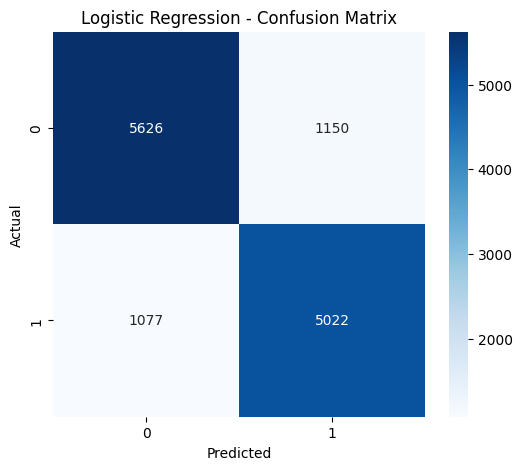

In [ ]:
cm = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(
            random_state=42,
            max_depth=6
        ))
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)

print("Decision Tree Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Results
--------------------------------
Accuracy : 0.9798834951456311
Precision: 0.9727979274611399
Recall   : 0.985079521232989
F1 Score : 0.9789002036659877

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6776
           1       0.97      0.99      0.98      6099

    accuracy                           0.98     12875
   macro avg       0.98      0.98      0.98     12875
weighted avg       0.98      0.98      0.98     12875



In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
--------------------------------
Accuracy : 0.9986019417475728
Precision: 0.999671322925226
Recall   : 0.9973766191178882
F1 Score : 0.9985226526592252

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_boosting_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            random_state=42
        ))
    ]
)

gradient_boosting_model.fit(X_train, y_train)

y_pred_gb = gradient_boosting_model.predict(X_test)

print("Gradient Boosting Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall   :", recall_score(y_test, y_pred_gb))
print("F1 Score :", f1_score(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Results
--------------------------------
Accuracy : 0.9964271844660194
Precision: 0.998025341451374
Recall   : 0.9944253156255124
F1 Score : 0.996222076215506

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      6776
           1       1.00      0.99      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    'Precision': [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_gb)
    ],
    'Recall': [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_gb)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_gb)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8270,0.8137,0.8234,0.8185
1,Decision Tree,0.9799,0.9728,0.9851,0.9789
2,Random Forest,0.9986,0.9997,0.9974,0.9985
3,Gradient Boosting,0.9964,0.9980,0.9944,0.9962


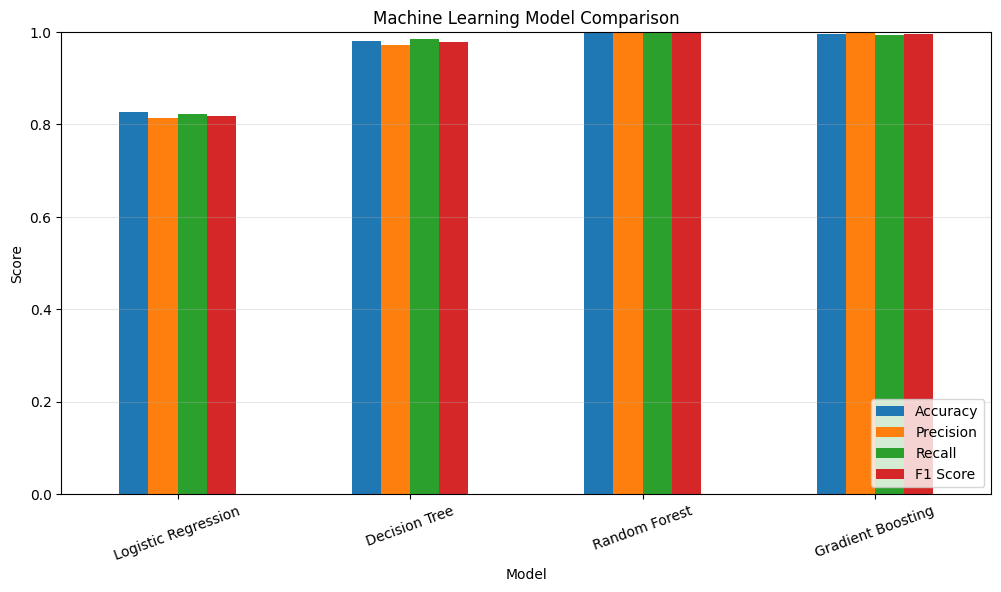

In [ ]:
results.set_index('Model').plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Machine Learning Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
best_model_row = results.loc[results['F1 Score'].idxmax()]

print("Best Model:", best_model_row['Model'])
print("Accuracy :", best_model_row['Accuracy'])
print("Precision:", best_model_row['Precision'])
print("Recall   :", best_model_row['Recall'])
print("F1 Score :", best_model_row['F1 Score'])

Best Model: Random Forest
Accuracy : 0.9986019417475728
Precision: 0.999671322925226
Recall   : 0.9973766191178882
F1 Score : 0.9985226526592252


In [ ]:
from sklearn.metrics import classification_report

# Create a dictionary of models
models = {
    'Logistic Regression': logistic_model,
    'Decision Tree': decision_tree_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model
}

# Get the name of the best model
best_model_name = best_model_row['Model']

# Get the selected model
best_model = models[best_model_name]

# Predictions
y_pred_best = best_model.predict(X_test)

# Classification report
print("Classification Report -", best_model_name)
print(classification_report(y_test, y_pred_best))

Classification Report - Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6776
           1       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



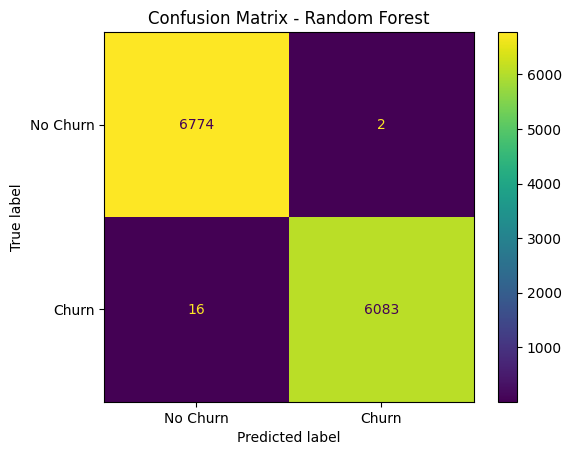

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

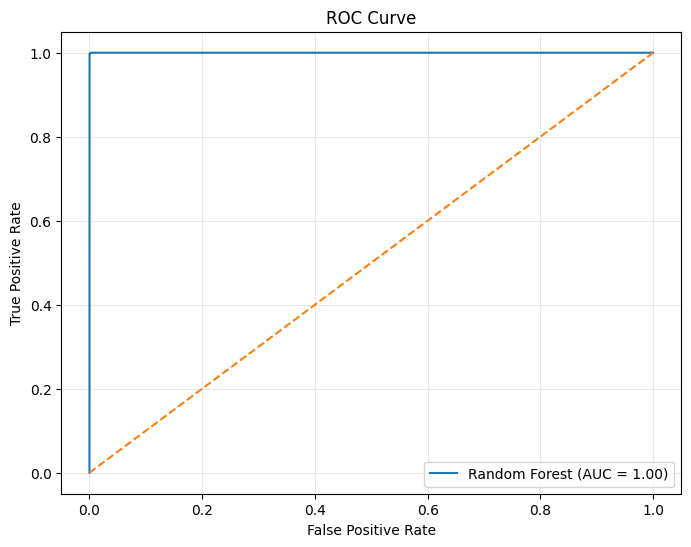

ROC-AUC Score: 0.9999963099027401


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

plt.show()

print("ROC-AUC Score:", auc_score)

In [ ]:
# Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the classifier within the pipeline
classifier = best_model.named_steps['classifier']
importance = classifier.feature_importances_

# Get feature names after preprocessing
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                            Feature  Importance
4                num__Payment Delay    0.436142
3                num__Support Calls    0.166725
1                       num__Tenure    0.115995
2              num__Usage Frequency    0.081905
5                  num__Total Spend    0.052609
0                          num__Age    0.040400
8                  cat__Gender_Male    0.032390
7                cat__Gender_Female    0.027113
13     cat__Contract Length_Monthly    0.013758
6             num__Last Interaction    0.012984
12      cat__Contract Length_Annual    0.008330
14   cat__Contract Length_Quarterly    0.006118
9      cat__Subscription Type_Basic    0.002124
10   cat__Subscription Type_Premium    0.001761
11  cat__Subscription Type_Standard    0.001646


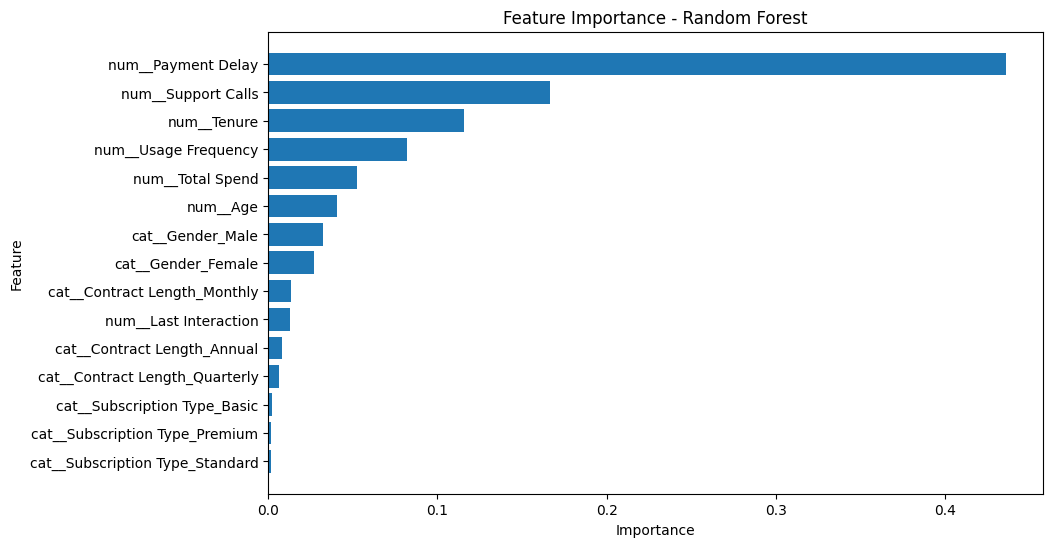

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f'Feature Importance - {best_model_name}')

plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Check which important variables currently exist

variables_to_check = [
    'X_train',
    'X_test',
    'y_train',
    'y_test',
    'rf_pipeline',
    'gb_pipeline',
    'rf_grid',
    'gb_grid',
    'best_model',
    'best_model_name',
    'feature_importance',
    'results'
]

for var in variables_to_check:
    print(f"{var}: {'EXISTS' if var in globals() else 'NOT FOUND'}")


X_train: NOT FOUND
X_test: NOT FOUND
y_train: NOT FOUND
y_test: NOT FOUND
rf_pipeline: NOT FOUND
gb_pipeline: NOT FOUND
rf_grid: NOT FOUND
gb_grid: NOT FOUND
best_model: NOT FOUND
best_model_name: NOT FOUND
feature_importance: NOT FOUND
results: NOT FOUND


In [ ]:
import os

print("Files available:")
for file in os.listdir():
    print(file)


Files available:
.config
customer_churn_dataset-testing-master.csv
sample_data


In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (64374, 12)

Column names:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

First 5 rows:


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0



Data types:
CustomerID            int64
Age                   int64
Gender               object
Tenure                int64
Usage Frequency       int64
Support Calls         int64
Payment Delay         int64
Subscription Type    object
Contract Length      object
Total Spend           int64
Last Interaction      int64
Churn                 int64
dtype: object

Missing values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


In [ ]:
print("Unique values in each column:\n")

for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")
    print(df[col].unique()[:10])
    print()


Unique values in each column:

CustomerID: 64374 unique values
[ 1  2  3  4  5  6  7  8  9 10]

Age: 48 unique values
[22 41 47 35 53 30 54 36 65 46]

Gender: 2 unique values
['Female' 'Male']

Tenure: 60 unique values
[25 28 27  9 58 41 37 36 20  8]

Usage Frequency: 30 unique values
[14 28 10 12 24 15 11  5  4 27]

Support Calls: 11 unique values
[ 4  7  2  5  9 10  0  6  1  3]

Payment Delay: 31 unique values
[27 13 29 17  2 10 28 18  8 23]

Subscription Type: 3 unique values
['Basic' 'Standard' 'Premium']

Contract Length: 3 unique values
['Monthly' 'Annual' 'Quarterly']

Total Spend: 901 unique values
[598 584 757 232 533 500 574 323 687 995]

Last Interaction: 30 unique values
[ 9 20 21 18 29 14 16  8 10  3]

Churn: 2 unique values
[1 0]



In [ ]:
# Make a copy so the original dataset remains unchanged
data = df.copy()

# Remove CustomerID because it is only an identifier
data = data.drop(columns=['CustomerID'])

# Separate features and target
X = data.drop(columns=['Churn'])
y = data['Churn']

print("Features:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(y.value_counts(normalize=True) * 100)


Features:
['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction']

Target distribution:
Churn
0    33881
1    30493
Name: count, dtype: int64

Target percentage:
Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify categorical and numerical columns
categorical_features = [
    'Gender',
    'Subscription Type',
    'Contract Length'
]

numerical_features = [
    col for col in X.columns
    if col not in categorical_features
]

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)


Training set: (51499, 10)
Testing set : (12875, 10)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

print("Random Forest trained successfully!")


Random Forest trained successfully!


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)

gb_pred = gb_pipeline.predict(X_test)

print("Gradient Boosting trained successfully!")


Gradient Boosting trained successfully!


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Random Forest predictions
rf_pred = rf_pipeline.predict(X_test)

# Gradient Boosting predictions
gb_pred = gb_pipeline.predict(X_test)

# Create comparison table
results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred),
        precision_score(y_test, gb_pred)
    ],
    'Recall': [
        recall_score(y_test, rf_pred),
        recall_score(y_test, gb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred)
    ]
})

display(results)


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.998602,0.999343,0.997705,0.998523
1,Gradient Boosting,0.999456,0.999672,0.999180,0.999426


In [ ]:
best_model_row = results.loc[results['F1 Score'].idxmax()]

best_model_name = best_model_row['Model']

if best_model_name == 'Random Forest':
    best_model = rf_pipeline
else:
    best_model = gb_pipeline

print("Best Model:", best_model_name)
print("Best F1 Score:", best_model_row['F1 Score'])


Best Model: Gradient Boosting
Best F1 Score: 0.9994259942599426


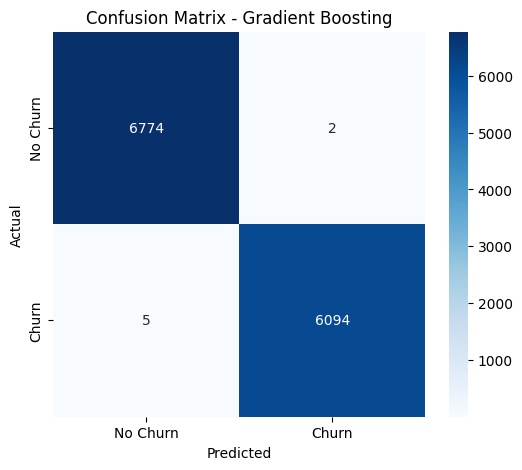

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')

plt.show()


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report -", best_model_name)
print(classification_report(
    y_test,
    y_pred,
    target_names=['No Churn', 'Churn']
))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00      6776
       Churn       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Final Model Performance")
print("------------------------")
print("Model     :", best_model_name)
print("Accuracy  :", round(accuracy, 4))
print("Precision :", round(precision, 4))
print("Recall    :", round(recall, 4))
print("F1 Score  :", round(f1, 4))

Final Model Performance
------------------------
Model     : Gradient Boosting
Accuracy  : 0.9995
Precision : 0.9997
Recall    : 0.9992
F1 Score  : 0.9994


Feature Importance:


,Feature,Importance
12,num__Payment Delay,0.437936
11,num__Support Calls,0.153835
9,num__Tenure,0.125396
10,num__Usage Frequency,0.082202
0,cat__Gender_Female,0.052584
8,num__Age,0.048192
1,cat__Gender_Male,0.039902
13,num__Total Spend,0.034222
6,cat__Contract Length_Monthly,0.016625
5,cat__Contract Length_Annual,0.007109


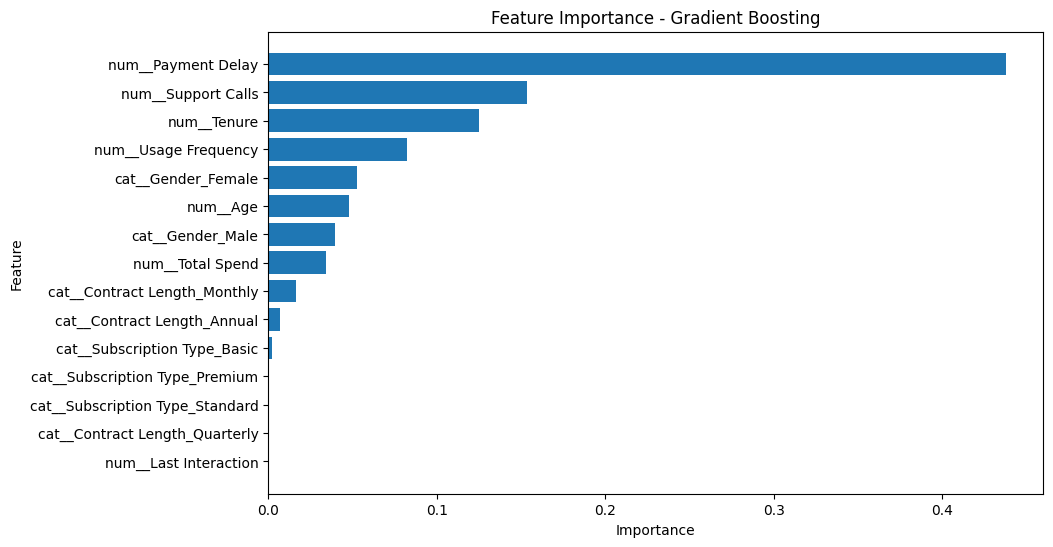

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from the classifier within the pipeline
classifier = best_model.named_steps['model'] # Access the 'model' step of the pipeline

# Check if the classifier has feature_importances_ (e.g., tree-based models)
if hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_

    # Get feature names after preprocessing
    feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

    # Create DataFrame
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    # Sort by importance
    feature_importance = feature_importance.sort_values(
        by='Importance',
        ascending=False
    )

    print("Feature Importance:")
    display(feature_importance)

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance['Feature'],
        feature_importance['Importance']
    )

    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.title(f'Feature Importance - {best_model_name}')

    plt.gca().invert_yaxis()
    plt.show()
else:
    print(f"The best model ({best_model_name}) does not have a 'feature_importances_' attribute.")
    print("Feature importance is typically available for tree-based models like Random Forest or Gradient Boosting.")


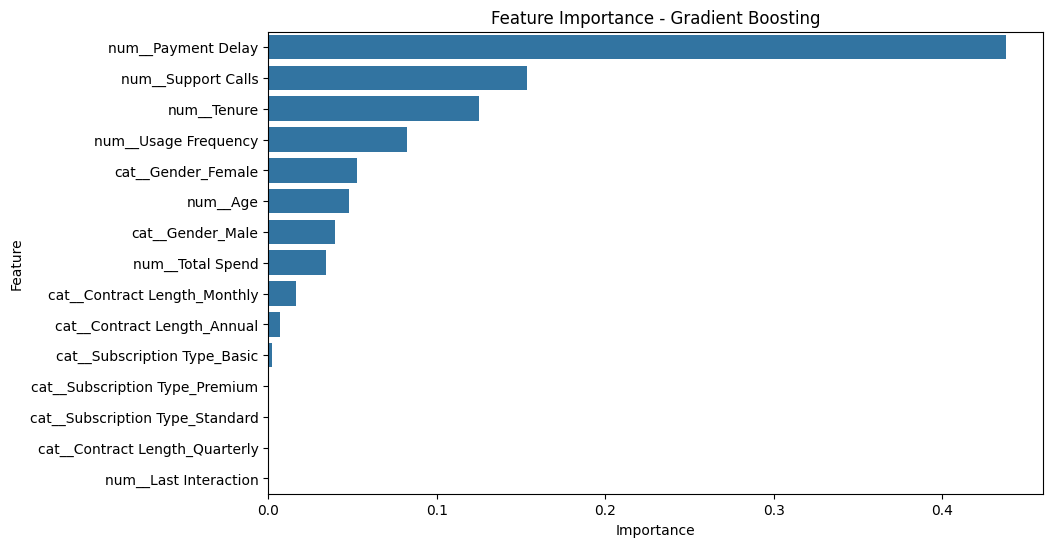

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance - Gradient Boosting')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

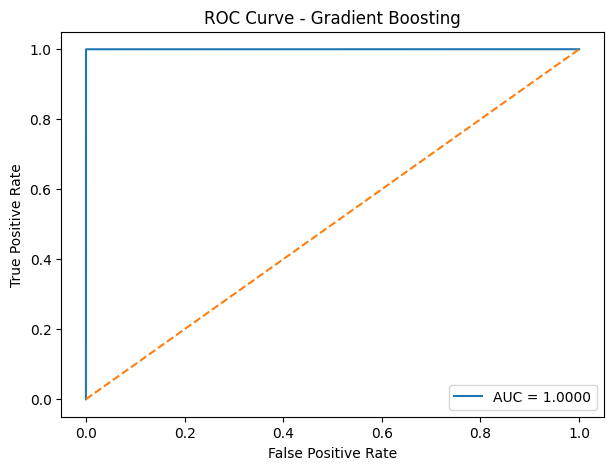

ROC-AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting')
plt.legend()
plt.show()

print("ROC-AUC Score:", round(auc_score, 4))

In [ ]:
# Example predictions
results = X_test.copy()

results['Actual Churn'] = y_test.values
results['Predicted Churn'] = y_pred

results.head(10)

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Actual Churn,Predicted Churn
7437,26,Male,51,19,6,3,Premium,Quarterly,761,21,0,0
54961,51,Female,7,4,7,0,Basic,Monthly,612,4,1,1
33685,52,Male,23,28,1,24,Premium,Annual,937,24,0,0
20607,48,Male,57,30,10,0,Standard,Monthly,362,22,0,0
34098,41,Female,45,27,5,9,Basic,Monthly,675,27,0,0
25054,26,Female,44,6,0,0,Basic,Monthly,226,11,0,0
21914,20,Male,45,10,0,19,Premium,Annual,606,20,0,0
42952,29,Female,4,16,5,2,Standard,Quarterly,796,26,0,0
26694,54,Male,31,27,7,11,Basic,Quarterly,412,28,0,0
18601,56,Female,28,8,7,6,Standard,Quarterly,542,21,0,0


In [ ]:
import joblib

joblib.dump(best_model, 'customer_churn_gradient_boosting_model.pkl')

print("Model saved successfully!")

Model saved successfully!
